# Supply Chain Demand Forecasting — Exploratory Data Analysis

- **Dataset:** M5 Forecasting Competition (Walmart retail sales, 2011-2016)  
- **Scope:** 30,490 item-store combinations across 3 product categories (FOODS,
  HOBBIES, HOUSEHOLD) and 10 stores in CA, TX, and WI  
- **Observation window:** 1,941 days (d_1 through d_1941), including the 28-day
  ground-truth evaluation period

---

## Purpose

This notebook has two goals:

1. **Validate the data** — confirm row counts, date ranges, null rates, and join integrity before any modelling work.
2. **Build the business case** — identify empirical patterns that justify the two core modelling decisions downstream:
   - **ABC classification** (rank SKUs by revenue contribution) → drives service-level targeting
   - **XYZ classification** (rank SKUs by demand variability) → drives safety-stock sizing

The findings here feed directly into Sprint 2 (ABC-XYZ segmentation) and Sprint 3 (feature engineering).  
Charts marked **[portfolio]** are candidates for the Quarto writeup.

---

## Structure

| **Section**        | **What it covers**                                         |
| :----------------- | :--------------------------------------------------------- |
| Load Data          | Schema validation, dtype optimization, merge integrity     |
| Prices             | Price distributions and inflation trends across categories |
| Sales Volume       | Revenue concentration (Pareto), top/bottom SKUs            |
| Temporal Patterns  | Day-of-week, monthly, and year-over-year seasonality       |
| Sparsity           | Zero-sales rates — proxy for demand intermittency          |
| Events & SNAP      | Measurable lift from holidays and SNAP disbursement days   |
| Demand Variability | Coefficient of variation distribution — the XYZ foundation |

In [1]:
%cd ..

/home/matt/Programming/repos/sc-demand-forecasting


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.blob_io import download_from_blob
from src.plotting import configure_matplotlib

configure_matplotlib()

In [3]:
DATA_DIR = Path("data").resolve()
assert DATA_DIR.exists()

CALENDAR_PATH = DATA_DIR / "calendar.csv"
PRICES_PATH = DATA_DIR / "sell_prices.csv"
SALES_PATH = DATA_DIR / "sales_train_evaluation.csv"

input_paths = [CALENDAR_PATH, PRICES_PATH, SALES_PATH]
missing_files = [path for path in input_paths if not path.exists()]
if missing_files:
    print(f"Missing {len(missing_files)} files. Downloading...\n")
    for path in missing_files:
        download_from_blob("raw", path.name, output_path=path)
else:
    print("No missing files.")

print(f"All {len(input_paths)} files are present:\n")
for path in input_paths:
    print(f"  '{path.name}'")

No missing files.
All 3 files are present:

  'calendar.csv'
  'sell_prices.csv'
  'sales_train_evaluation.csv'


## Helpers

In [4]:
def summarize_data(df: pd.DataFrame, index: bool=False) -> pd.DataFrame:
    """
    Returns a summary of data types, nulls, memory usage, and example values.
    """
    summary = pd.DataFrame({
        "# Null":  df.isna().sum(),
        "% Null":  df.isna().mean(),
        "Memory Usage":  df.memory_usage(index=index),
    })
    
    # Add "# Values" and sum (Total = Total values in DataFrame)
    summary.insert(1, "# Values", len(df))  # After "# Null"
    summary.loc["Total"] = summary.sum(axis=0, numeric_only=True)

    summary.insert(0, "DType", df.dtypes)
    summary = pd.concat([summary, df.head(3).transpose()], axis=1)
    
    # Remaining values are strings -- fill with blank
    summary = summary.fillna("")

    # Format numbers
    format_integer = "{:,.0f}".format
    format_percent = "{:,.2%}".format
    def format_bytes(size: int) -> str:
        unit_index = int(np.log(size) // np.log(1024))
        units = ["B", "KB", "MB", "GB"][unit_index]
        size_in_units = size / (1024 ** unit_index)
        if size_in_units >= 100:
            return f"{size_in_units:,.0f} {units}"
        if size_in_units >= 10:
            return f"{size_in_units:.1f} {units}"
        else:
            return f"{size_in_units:.2f} {units}"
        
    summary["# Null"] = summary["# Null"].map(format_integer)
    summary["# Values"] = summary["# Values"].map(format_integer)
    summary["% Null"] = summary["% Null"].map(format_percent)
    summary["Memory Usage"] = summary["Memory Usage"].map(format_bytes)

    summary = (
        summary
        .rename_axis("Column", axis=0)
        .reset_index()
        .set_index([
            "Column", "DType", "# Null", "# Values", "% Null", "Memory Usage"
        ])
        .rename_axis("Values", axis=1)
    )

    return summary

## Load Data

### Calendar

In [5]:
summarize_data(pd.read_csv(CALENDAR_PATH))

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
date,object,0,"1,969",0.00%,15.4 KB,2011-01-29,2011-01-30,2011-01-31
wm_yr_wk,int64,0,"1,969",0.00%,15.4 KB,11101,11101,11101
weekday,object,0,"1,969",0.00%,15.4 KB,Saturday,Sunday,Monday
wday,int64,0,"1,969",0.00%,15.4 KB,1,2,3
month,int64,0,"1,969",0.00%,15.4 KB,1,1,1
year,int64,0,"1,969",0.00%,15.4 KB,2011,2011,2011
d,object,0,"1,969",0.00%,15.4 KB,d_1,d_2,d_3
event_name_1,object,"1,807","1,969",91.77%,15.4 KB,,,
event_type_1,object,"1,807","1,969",91.77%,15.4 KB,,,


Not a lot to do on this one -- just need to parse the dates. Also, to save some
space, I'm going to convert `d` to type category -- this will save a ton of
space when we join on the Sales data.

In [6]:
calendar = pd.read_csv(CALENDAR_PATH, parse_dates=["date"])
calendar = calendar.astype({"d": "category", "weekday": "category"})
summarize_data(calendar)

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
date,datetime64[ns],0,"1,969",0.00%,15.4 KB,2011-01-29 00:00:00,2011-01-30 00:00:00,2011-01-31 00:00:00
wm_yr_wk,int64,0,"1,969",0.00%,15.4 KB,11101,11101,11101
weekday,category,0,"1,969",0.00%,2.27 KB,Saturday,Sunday,Monday
wday,int64,0,"1,969",0.00%,15.4 KB,1,2,3
month,int64,0,"1,969",0.00%,15.4 KB,1,1,1
year,int64,0,"1,969",0.00%,15.4 KB,2011,2011,2011
d,category,0,"1,969",0.00%,83.8 KB,d_1,d_2,d_3
event_name_1,object,"1,807","1,969",91.77%,15.4 KB,,,
event_type_1,object,"1,807","1,969",91.77%,15.4 KB,,,


No major issues -- can keep as-is.

### Prices

In [7]:
summarize_data(pd.read_csv(PRICES_PATH))

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
store_id,object,0,"6,841,121",0.00%,52.2 MB,CA_1,CA_1,CA_1
item_id,object,0,"6,841,121",0.00%,52.2 MB,HOBBIES_1_001,HOBBIES_1_001,HOBBIES_1_001
wm_yr_wk,int64,0,"6,841,121",0.00%,52.2 MB,11325,11326,11327
sell_price,float64,0,"6,841,121",0.00%,52.2 MB,9.58,9.58,8.26
Total,,0,"27,364,484",0.00%,209 MB,,,


From the [data dictionary](../docs/data-dictionary.md), we know that the prices
data doesn't have data for ever week. Will need to fill in missing values at
some point, but for EDA we can skip this -- only look at prices when the
products were sold. For now, can do a **forward fill** first, then a **backfill**
for anything remaining.

Right now, the data isn't showing any null values -- the rows simply aren't
present when there are no sales. To fix this and apply the forward-fill:

1. Pivot the store/item to the index and the week to the columns.
2. Apply the forward fill + backfill along `axis=1`.
3. Unpivot (melt) back to long-form.

In [8]:
prices = pd.read_csv(PRICES_PATH)

# Pivot then un-pivot to get the full range of values
prices = (
    prices
    .pivot(
        index=["store_id", "item_id"],
        columns="wm_yr_wk",
        values="sell_price",
    )
    .ffill(axis=1)
    .bfill(axis=1)
    .reset_index()
    .melt(
        id_vars=["store_id", "item_id"],
        value_vars=None, # Infer - remaining columns
        var_name="wm_yr_wk",
        value_name="sell_price",
    )
    .astype({
        "store_id": "category",
        "item_id": "category",
        "wm_yr_wk": int,
        "sell_price": float,
    })
)

summarize_data(prices)

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
store_id,category,0,"8,598,180",0.00%,8.20 MB,CA_1,CA_1,CA_1
item_id,category,0,"8,598,180",0.00%,16.5 MB,FOODS_1_001,FOODS_1_002,FOODS_1_003
wm_yr_wk,int64,0,"8,598,180",0.00%,65.6 MB,11101,11101,11101
sell_price,float64,0,"8,598,180",0.00%,65.6 MB,2.0,7.88,2.88
Total,,0,"34,392,720",0.00%,156 MB,,,


### Sales

In [9]:
summarize_data(pd.read_csv(SALES_PATH))

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
id,object,0,"30,490",0.00%,238 KB,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_003_CA_1_evaluation
item_id,object,0,"30,490",0.00%,238 KB,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003
dept_id,object,0,"30,490",0.00%,238 KB,HOBBIES_1,HOBBIES_1,HOBBIES_1
cat_id,object,0,"30,490",0.00%,238 KB,HOBBIES,HOBBIES,HOBBIES
store_id,object,0,"30,490",0.00%,238 KB,CA_1,CA_1,CA_1
...,...,...,...,...,...,...,...,...
d_1938,int64,0,"30,490",0.00%,238 KB,3,0,2
d_1939,int64,0,"30,490",0.00%,238 KB,3,0,3
d_1940,int64,0,"30,490",0.00%,238 KB,0,0,0


Sales comes with a few identifying columns, but the `d_1` through `d_1941` will
have to be un-pivoted. These are sales units columns. 

Also, the `id` column isn't really needed -- it doesn't add any additional
information.

In [10]:
sales = pd.read_csv(SALES_PATH)

sales = (
    sales
    .drop(columns=["id", "dept_id", "cat_id", "state_id"])
    .melt(
        id_vars=["item_id", "store_id"],
        value_vars=None, # Infer remaining
        var_name="d",
        value_name="sales_units",
    )
    .astype({col: "category" for col in ["item_id", "store_id", "d"]})
)

summarize_data(sales)

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
item_id,category,0,"59,181,090",0.00%,113 MB,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003
store_id,category,0,"59,181,090",0.00%,56.4 MB,CA_1,CA_1,CA_1
d,category,0,"59,181,090",0.00%,113 MB,d_1,d_1,d_1
sales_units,int64,0,"59,181,090",0.00%,452 MB,0,0,0
Total,,0,"236,724,360",0.00%,734 MB,,,


This is a very large DataFrame -- 734 MB. Note that this is down from 3.53 GB
when we kept the strings as `str` dtype instead of `category`.

### Merge Data

In [11]:
df = (
    sales
    .merge(
        calendar[["d", "date", "wm_yr_wk"]],
        how="left",
        on="d",
        validate="m:1",
    )
    .drop(columns="d")
    .merge(
        prices,
        how="left",
        on=["store_id", "item_id", "wm_yr_wk"],
        validate="m:1",
    )
    .drop(columns="wm_yr_wk")
)

display(summarize_data(df))
df.head()

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
item_id,category,0,"59,181,090",0.00%,113 MB,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003
store_id,category,0,"59,181,090",0.00%,56.4 MB,CA_1,CA_1,CA_1
sales_units,int64,0,"59,181,090",0.00%,452 MB,0,0,0
date,datetime64[ns],0,"59,181,090",0.00%,452 MB,2011-01-29 00:00:00,2011-01-29 00:00:00,2011-01-29 00:00:00
sell_price,float64,0,"59,181,090",0.00%,452 MB,9.58,3.97,2.97
Total,,0,"295,905,450",0.00%,1.49 GB,,,


,item_id,store_id,sales_units,date,sell_price
0,HOBBIES_1_001,CA_1,0,2011-01-29,9.58
1,HOBBIES_1_002,CA_1,0,2011-01-29,3.97
2,HOBBIES_1_003,CA_1,0,2011-01-29,2.97
3,HOBBIES_1_004,CA_1,0,2011-01-29,4.34
4,HOBBIES_1_005,CA_1,0,2011-01-29,2.98


## Exploration

In [12]:
df = df.assign(
    dept_id=df["item_id"].str.rsplit("_", n=1).str[0].astype("category"),
    cat_id=df["item_id"].str.split("_").str[0].astype("category"),
    state_id=df["store_id"].str.split("_").str[0].astype("category"),
    sales_amount=df["sales_units"].mul(df["sell_price"]),
)

### Prices

/tmp/ipykernel_13997/646873.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


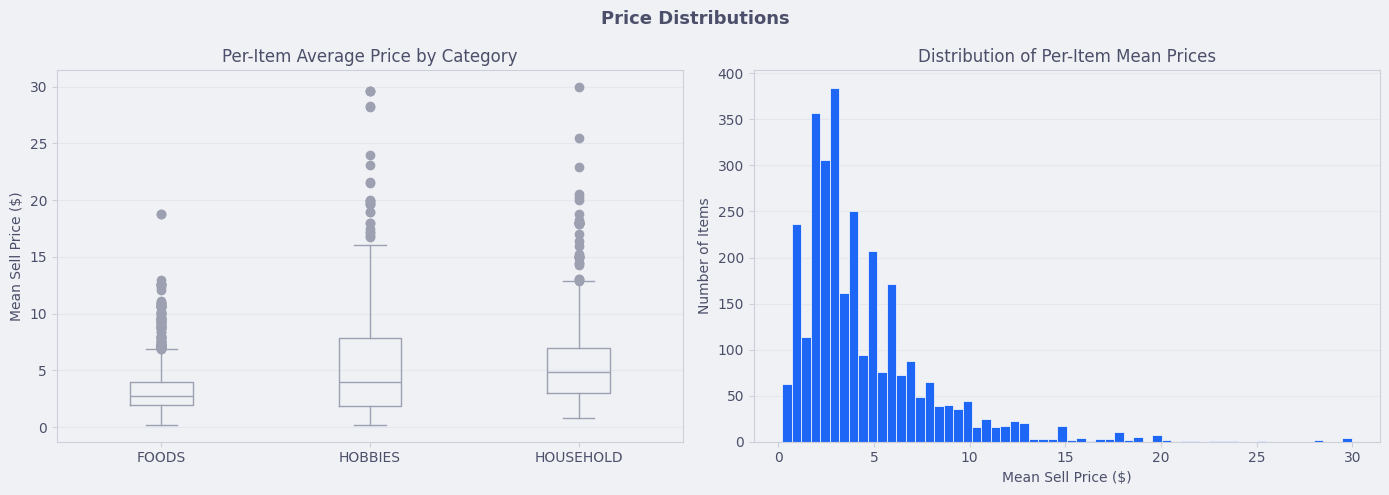

In [29]:
item_prices = (
    df.groupby(["item_id", "cat_id"], observed=True)["sell_price"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats = item_prices["cat_id"].cat.categories
axes[0].boxplot(
    [item_prices.loc[item_prices["cat_id"] == c, "sell_price"].values for c in cats],
    labels=cats,
)
axes[0].set_title("Per-Item Average Price by Category")
axes[0].set_ylabel("Mean Sell Price ($)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(item_prices["sell_price"], bins=60, edgecolor="white", linewidth=0.5)
axes[1].set_title("Distribution of Per-Item Mean Prices")
axes[1].set_xlabel("Mean Sell Price ($)")
axes[1].set_ylabel("Number of Items")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle("Price Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

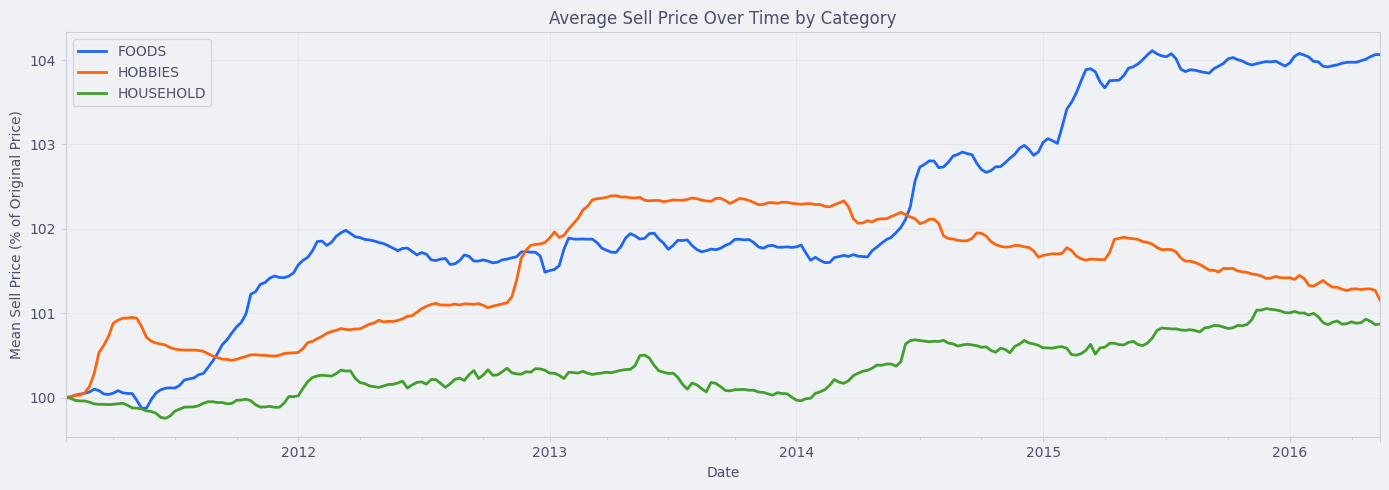

In [35]:
weekly_prices = (
    df
    .assign(week=df["date"].dt.to_period("W").dt.to_timestamp())
    .pivot_table(
        index="week",
        columns="cat_id",
        values="sell_price",
        aggfunc="mean",
        observed=True,
    )
    .apply(lambda s: s.div(s.iloc[0]).mul(100), axis=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
weekly_prices.plot(ax=ax, kind="line", linewidth=2)

ax.set_title("Average Sell Price Over Time by Category")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Sell Price (% of Original Price)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Prices vary substantially across and within categories — HOBBIES items show a long right tail of expensive SKUs, while FOODS clusters at the lower end. Crucially, mean prices are not static: the time-series above shows a slow upward drift across all three categories, consistent with retail inflation over the 2011–2016 window.

Both facts argue for treating price as a dynamic feature rather than a constant: the feature pipeline (Sprint 3) will include sell price level, week-over-week price change, and price relative to the category mean.

### Sales Volume

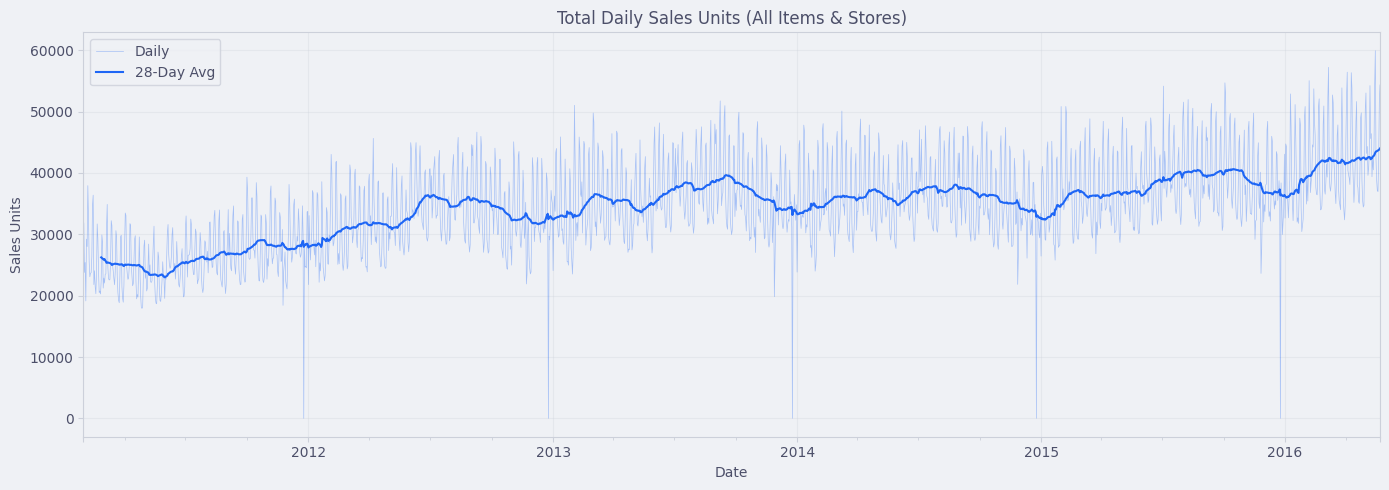

In [36]:
daily_sales = df.groupby("date")["sales_units"].sum()
rolling = daily_sales.rolling(28).mean()

fix, ax = plt.subplots(figsize=(14, 5))
daily_sales.plot(
    ax=ax,
    kind="line",
    label="Daily",
    color="C0",
    alpha=0.35,
    linewidth=0.5,
)
rolling.plot(color="C0", linewidth=1.5, label="28-Day Avg")

ax.set_title("Total Daily Sales Units (All Items & Stores)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales Units")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

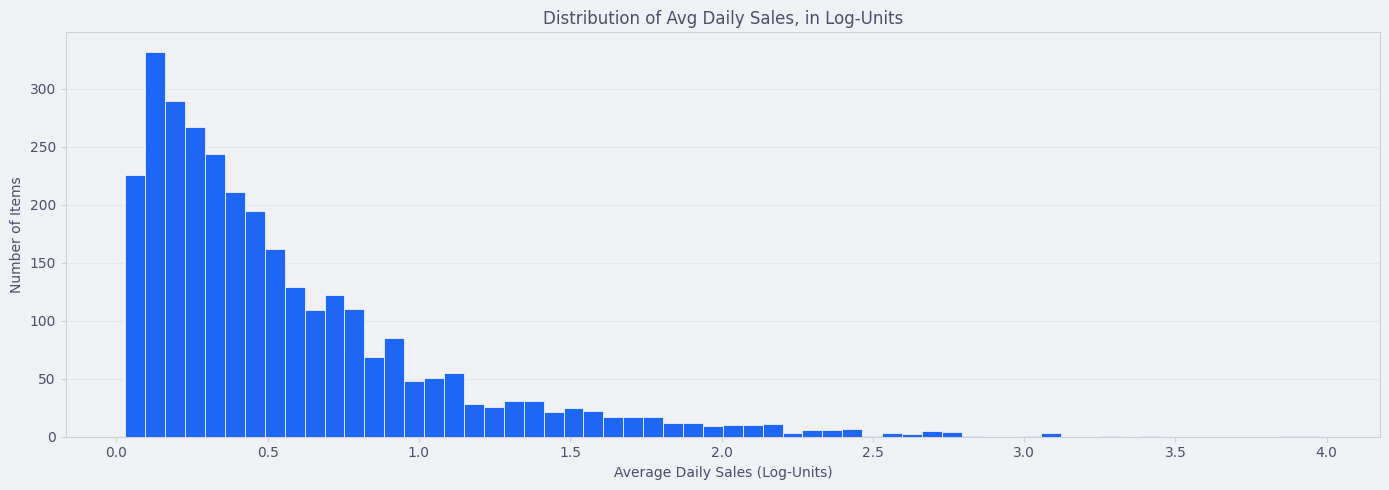

In [37]:
sales_by_product = (
    df
    .groupby("item_id", observed=True)
    ["sales_units"].mean()
    .map(np.log1p)
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(sales_by_product, bins=60, edgecolor="white", linewidth=0.5)
ax.set_title("Distribution of Avg Daily Sales, in Log-Units")
ax.set_xlabel("Average Daily Sales (Log-Units)")
ax.set_ylabel("Number of Items")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

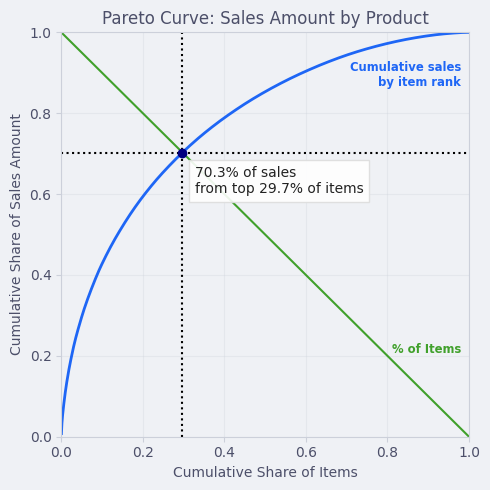

In [92]:
# Pareto by Product
sales_pareto = (
    df
    .groupby("item_id", observed=True)  # observed=True => exclude unused cats
    ["sales_amount"].sum()
    .sort_values(ascending=False)
    .div(df["sales_amount"].sum())
    .cumsum()
    .to_frame("percent_of_sales")
)
sales_pareto["percent_of_items"] = (
    np.arange(1, len(sales_pareto) + 1) / len(sales_pareto)
)
x = sales_pareto["percent_of_items"].to_numpy()
y = sales_pareto["percent_of_sales"].to_numpy()

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(x, y, linewidth=2)
ax.text(
    0.98, 0.93,
    "Cumulative sales\nby item rank",
    color="C0",
    fontweight="bold",
    ha="right",
    va="top",
    fontsize="small",
)

ax.plot([0, 1], [1, 0], color="C2", linewidth=1.5)
ax.text(
    0.98, 0.20,
    "% of Items",
    color="C2",
    fontweight="bold",
    ha="right",
    va="bottom",
    fontsize="small",
)

# Find where y% of sales is explained by (1-y)% of items, i.e. x + y = 1
idx = np.argmin(np.abs(x + y - 1.0))
x_cross, y_cross = x[idx], y[idx]

ax.axhline(y_cross, color="k", linestyle=":", linewidth=1.5)
ax.axvline(x_cross, color="k", linestyle=":", linewidth=1.5)
ax.scatter([x_cross], [y_cross], color="navy", zorder=3)
ax.text(
    x_cross + 0.03, y_cross - 0.10,
    f"{y_cross:.1%} of sales\nfrom top {x_cross:.1%} of items",
    color="#222",
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#ddd"},
)

ax.set_title("Pareto Curve: Sales Amount by Product")
ax.set_xlabel("Cumulative Share of Items")
ax.set_ylabel("Cumulative Share of Sales Amount")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The Pareto crossover point — annotated on the chart — shows that a small fraction of SKUs account for the overwhelming majority of total revenue. This is the empirical justification for **ABC classification**: ranking items by cumulative revenue contribution and grouping them into tiers with differentiated inventory policies.

* **A-items** — top ~70 % of cumulative revenue (few SKUs, high individual value)
* **B-items** — next ~20 % of cumulative revenue
* **C-items** — bottom ~10 % of cumulative revenue (many SKUs, negligible individual value)

Applying a 99 % service level uniformly across all tiers wastes capital on C-items while the same budget could buffer A-item stockouts that actually hurt revenue.

### Top-10 / Bottom-10 SKUs by Revenue

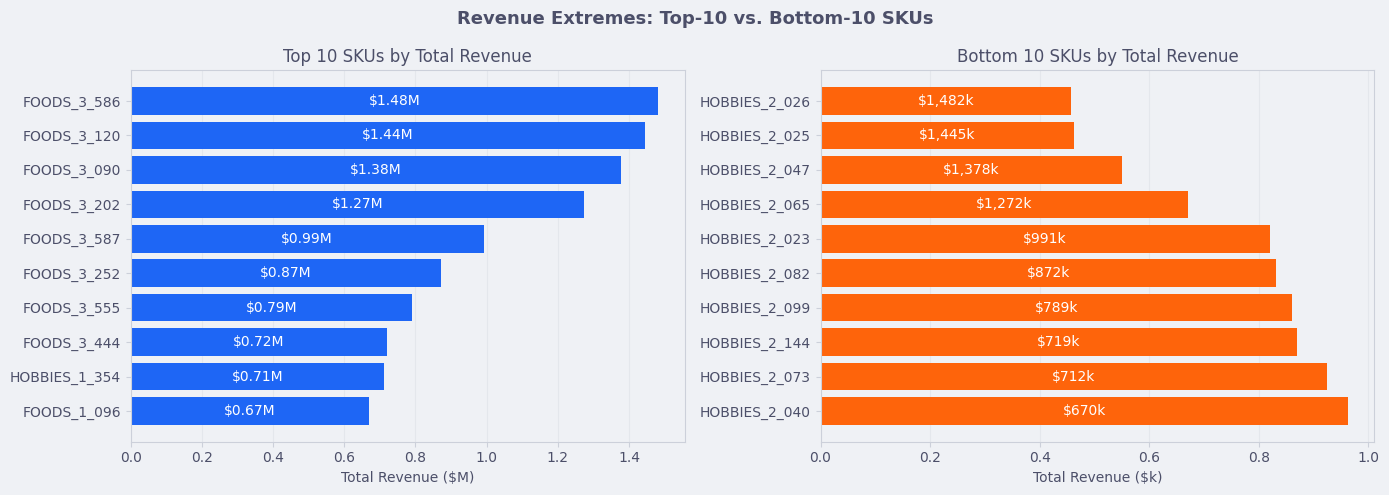

Top-10 revenue range : $670,077 – $1,482,295
Bottom-10 revenue range: $457.93 – $962.72


In [100]:
sku_revenue = (
    df.groupby("item_id", observed=True)["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"sales_amount": "total_revenue"})
)

top10 = sku_revenue.head(10)
bottom10 = sku_revenue.tail(10).sort_values("total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10["item_id"].astype(str), top10["total_revenue"].div(1e6), color="C0")
axes[0].set_title("Top 10 SKUs by Total Revenue")
axes[0].set_xlabel("Total Revenue ($M)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_axisbelow(True)
axes[0].bar_label(
    axes[0].containers[0],
    top10["total_revenue"].div(1e6).map("${:,.2f}M".format),
    label_type="center",
    color="white",
)

axes[1].barh(bottom10["item_id"].astype(str), bottom10["total_revenue"].div(1e3), color="C1")
axes[1].set_title("Bottom 10 SKUs by Total Revenue")
axes[1].set_xlabel("Total Revenue ($k)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].bar_label(
    axes[1].containers[0],
    top10["total_revenue"].div(1000).map("${:,.0f}k".format),
    label_type="center",
    color="white",
)

plt.suptitle("Revenue Extremes: Top-10 vs. Bottom-10 SKUs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Top-10 revenue range : ${top10['total_revenue'].min():,.0f} – ${top10['total_revenue'].max():,.0f}")
print(f"Bottom-10 revenue range: ${bottom10['total_revenue'].min():,.2f} – ${bottom10['total_revenue'].max():,.2f}")


The revenue gap between the top and bottom deciles is printed above. Top-10 SKUs each generate thousands of dollars; bottom-10 SKUs generate fractions of a cent per day on average — a difference of several orders of magnitude. This is not a reason to stop stocking bottom-10 items; it *is* a reason to stop optimising their safety stock with the same costly service-level targets applied to the top-10. **[portfolio]**

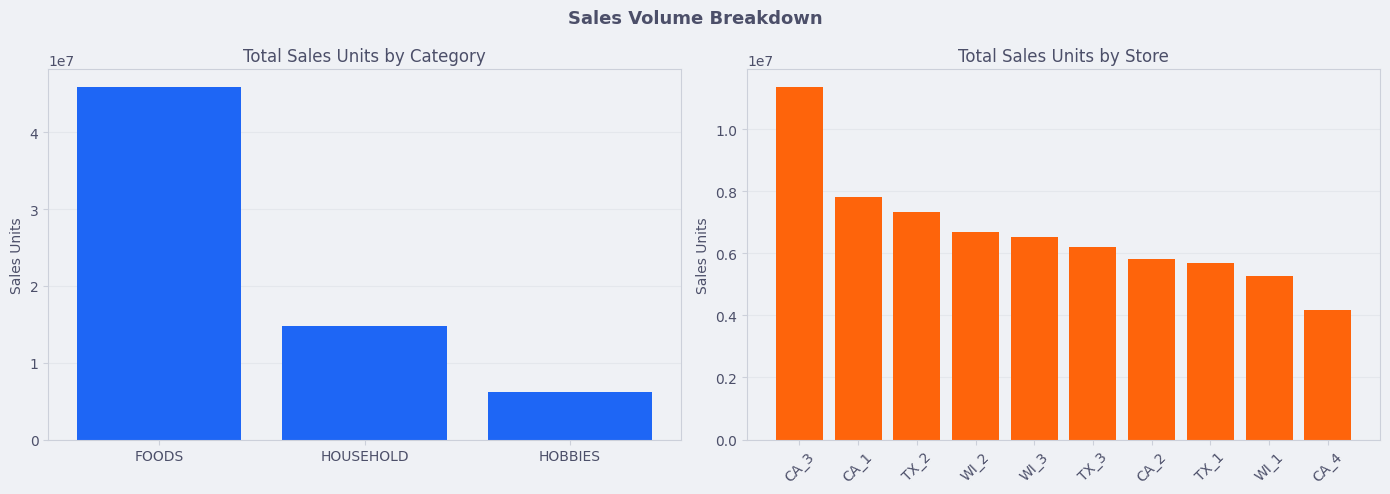

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales = (
    df
    .groupby("cat_id", observed=True)
    ["sales_units"].sum()
    .sort_values(ascending=False)
)
axes[0].bar(cat_sales.index.astype(str), cat_sales.values, color="C0")
axes[0].set_title("Total Sales Units by Category")
axes[0].set_ylabel("Sales Units")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

store_sales = (
    df
    .groupby("store_id", observed=True)
    ["sales_units"].sum()
    .sort_values(ascending=False)
)
axes[1].bar(store_sales.index.astype(str), store_sales.values, color="C1")
axes[1].set_title("Total Sales Units by Store")
axes[1].set_ylabel("Sales Units")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle("Sales Volume Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

FOODS dominates by unit volume — more than double HOBBIES and HOUSEHOLD combined. Across stores, volume is relatively balanced with no single outlet outsized, which means store-level features (store_id) will add signal without being dominated by one location. The category imbalance is relevant for the ABC-XYZ matrix: FOODS items are likely to over-represent the A and X tiers simply due to volume, so per-category service-level calibration may be warranted.

### Temporal Patterns

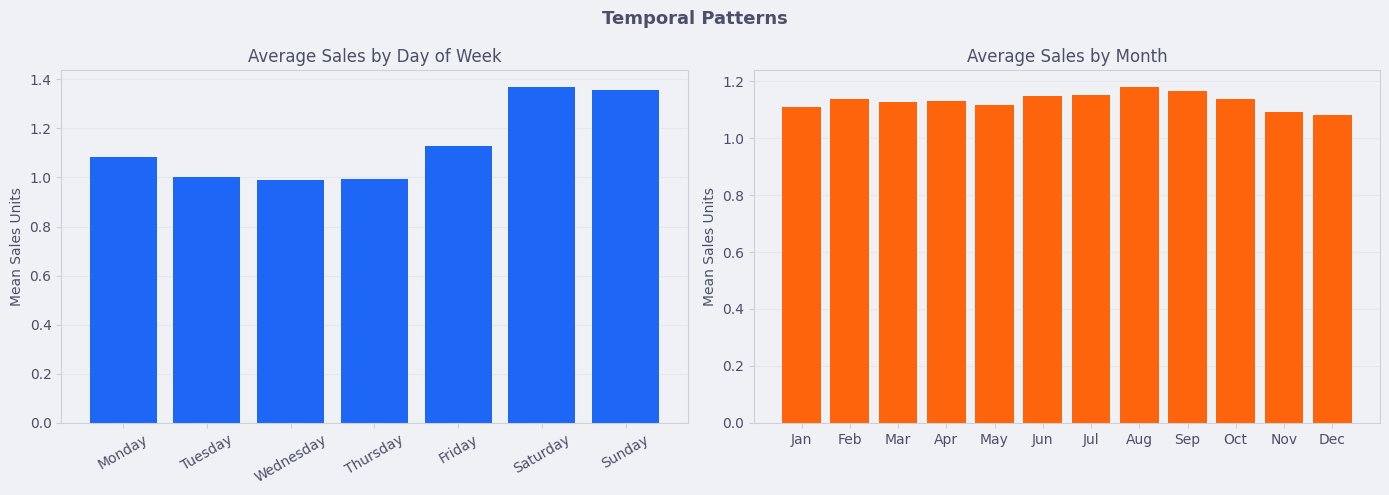

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = (
    df.assign(dow=df["date"].dt.day_name())
    .groupby("dow")["sales_units"]
    .mean()
    .reindex(dow_order)
)
axes[0].bar(dow_sales.index, dow_sales.values, color="C0")
axes[0].set_title("Average Sales by Day of Week")
axes[0].set_ylabel("Mean Sales Units")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_sales = df.assign(month=df["date"].dt.month).groupby("month")["sales_units"].mean()
axes[1].bar(month_labels, month_sales.values, color="C1")
axes[1].set_title("Average Sales by Month")
axes[1].set_ylabel("Mean Sales Units")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle("Temporal Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Two clear patterns emerge. First, **within-week seasonality**: weekend days average noticeably more units than weekdays, with Saturday the peak. Second, **within-year seasonality**: December is the highest-sales month by a wide margin, with a secondary lift in the spring. Both patterns are strong enough that a model without calendar features would systematically misforecast the peaks and troughs — day-of-week, month, and holiday indicators are non-negotiable features.

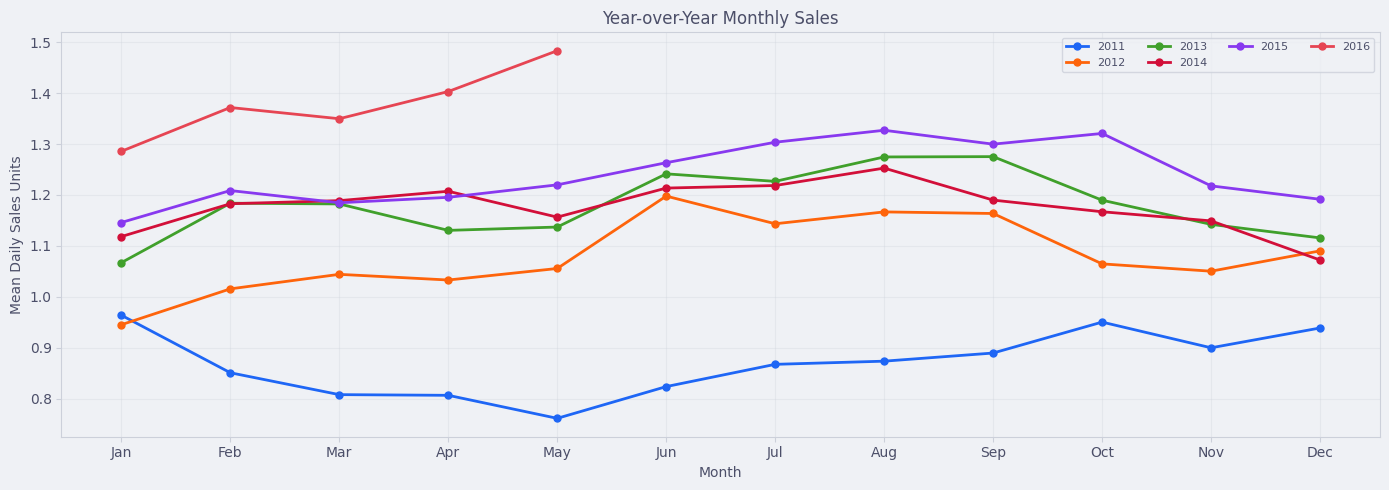

In [105]:
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
yoy = (
    df.assign(year=df["date"].dt.year, month=df["date"].dt.month)
    .groupby(["year", "month"])["sales_units"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for year in sorted(yoy["year"].unique()):
    sub = yoy[yoy["year"] == year]
    ax.plot(
        sub["month"],
        sub["sales_units"],
        marker="o",
        markersize=5,
        linewidth=2,
        label=str(year),
    )

ax.set_title("Year-over-Year Monthly Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Daily Sales Units")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The year-over-year overlay shows that the seasonal *shape* is stable across all years — the December peak and spring lift appear consistently. This matters for modelling: it means week-of-year and month features will generalise across the training window rather than picking up noise from a single anomalous year. The gradual upward shift in the baseline (each successive year sits slightly higher) reflects the same long-run volume growth visible in the daily sales trend above. **[portfolio]**

### Sparsity

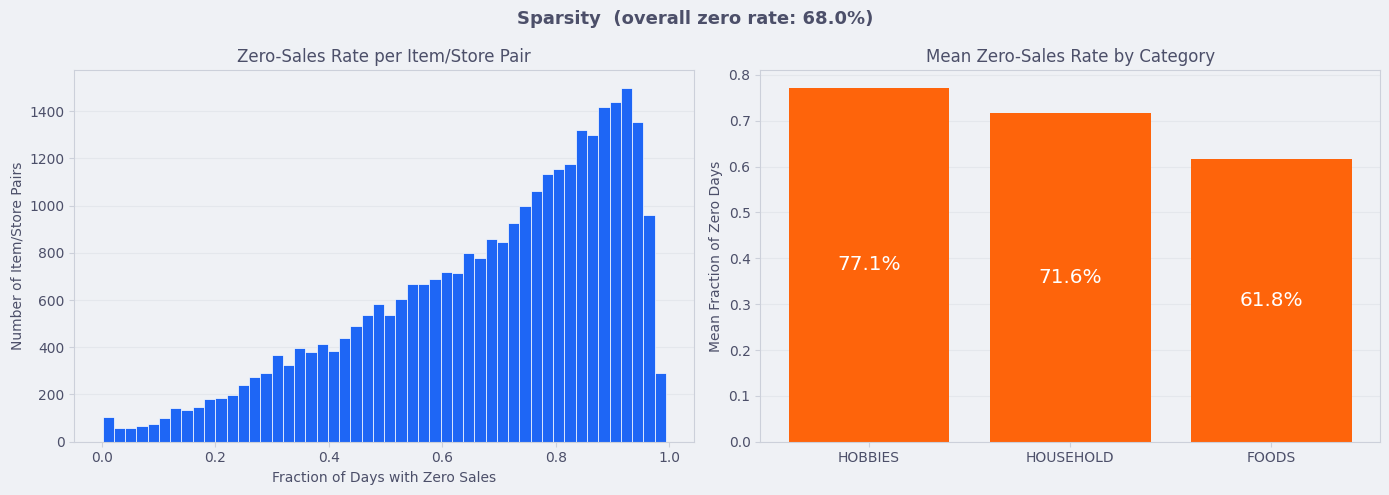

In [110]:
zero_rate = (
    df.assign(is_zero=(df["sales_units"] == 0))
    .groupby(["item_id", "store_id"], observed=True)["is_zero"]
    .mean()
    .reset_index(name="zero_rate")
)
zero_rate["cat_id"] = zero_rate["item_id"].str.split("_").str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(zero_rate["zero_rate"], bins=50, edgecolor="white", linewidth=0.5, color="C0")
axes[0].set_title("Zero-Sales Rate per Item/Store Pair")
axes[0].set_xlabel("Fraction of Days with Zero Sales")
axes[0].set_ylabel("Number of Item/Store Pairs")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

cat_zero = zero_rate.groupby("cat_id")["zero_rate"].mean().sort_values(ascending=False)
container = axes[1].bar(cat_zero.index, cat_zero.values, color="C1")
axes[1].bar_label(
    container,
    cat_zero.map("{:.1%}".format),
    label_type="center",
    color="white",
    size="x-large",
)
axes[1].set_title("Mean Zero-Sales Rate by Category")
axes[1].set_ylabel("Mean Fraction of Zero Days")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

overall_zero = (df["sales_units"] == 0).mean()
plt.suptitle(f"Sparsity  (overall zero rate: {overall_zero:.1%})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The distribution is bimodal: one cluster of item-store pairs sells on nearly every day (zero-rate near 0), another sells rarely or never (zero-rate near 1). This wide spread is a direct proxy for demand variability and previews the XYZ classification coming in Sprint 2: high zero-rate series will almost certainly fall in the Z tier (CV ≥ 1.0) and require a fundamentally different inventory policy than the stable, high-velocity items on the left of the distribution.

### Events & SNAP

In [23]:
# Aggregate to daily/state level before joining calendar to keep memory low
date_event = calendar.set_index("date")[["event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]]
daily_by_state = (
    df.groupby(["date", "state_id"], observed=True)["sales_units"]
    .mean()
    .reset_index()
    .join(date_event, on="date")
)
daily_by_state["has_event"] = daily_by_state["event_name_1"].notna()

Avg daily sales on non-event days : 1.124
Avg daily sales on event days     : 1.073
Event lift                        : -4.5%


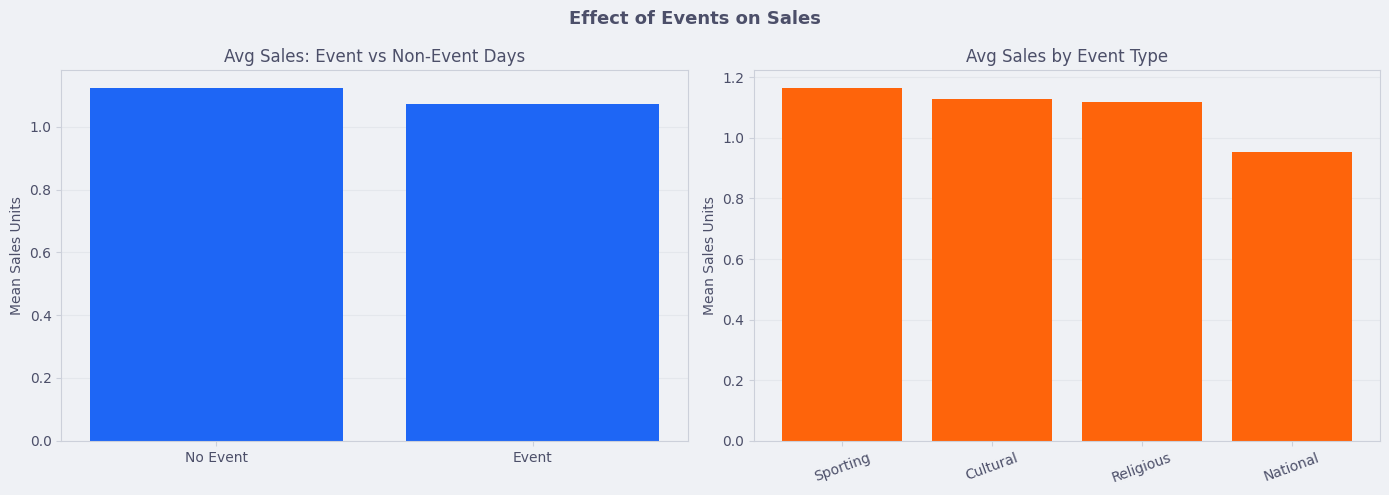

In [111]:
event_avg = daily_by_state.groupby("has_event")["sales_units"].mean()
print(f"Avg daily sales on non-event days : {event_avg[False]:.3f}")
print(f"Avg daily sales on event days     : {event_avg[True]:.3f}")
print(f"Event lift                        : {event_avg[True] / event_avg[False] - 1:+.1%}")

type_avg = (
    daily_by_state.dropna(subset=["event_type_1"])
    .groupby("event_type_1")["sales_units"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["No Event", "Event"], event_avg.values, color="C0")
axes[0].set_title("Avg Sales: Event vs Non-Event Days")
axes[0].set_ylabel("Mean Sales Units")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

axes[1].bar(type_avg.index, type_avg.values, color="C1")
axes[1].set_title("Avg Sales by Event Type")
axes[1].set_ylabel("Mean Sales Units")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle("Effect of Events on Sales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

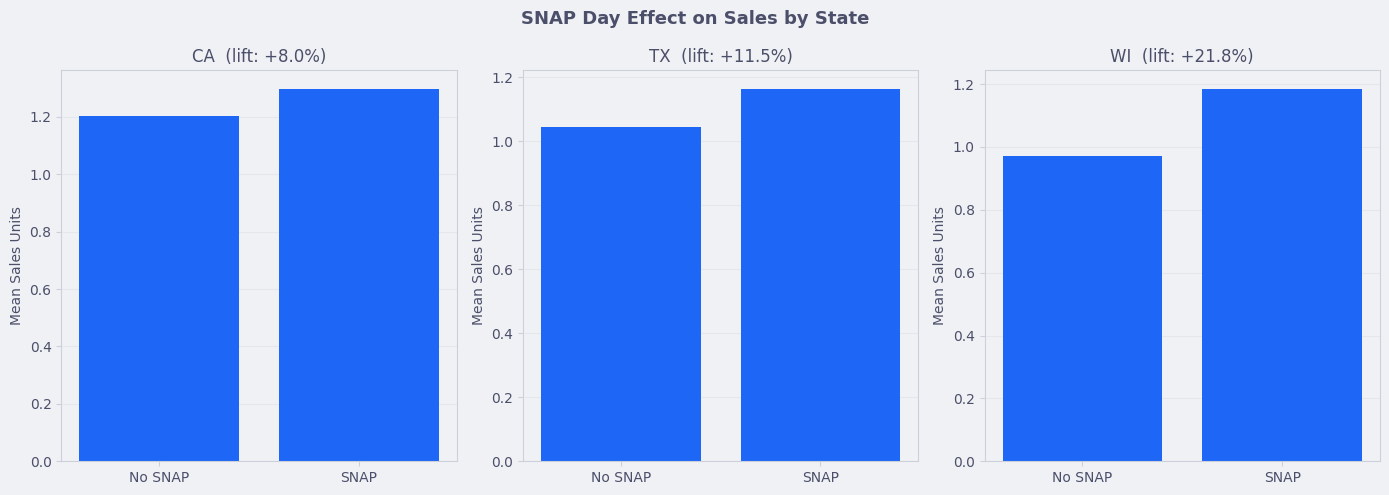

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (state, col) in zip(axes, [("CA", "snap_CA"), ("TX", "snap_TX"), ("WI", "snap_WI")]):
    state_data = daily_by_state[daily_by_state["state_id"] == state]
    snap_avg = state_data.groupby(col)["sales_units"].mean()
    lift = snap_avg[1] / snap_avg[0] - 1
    ax.bar(["No SNAP", "SNAP"], snap_avg.values)
    ax.set_title(f"{state}  (lift: {lift:+.1%})")
    ax.set_ylabel("Mean Sales Units")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("SNAP Day Effect on Sales by State", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SNAP disbursement days produce a consistent, measurable lift in average daily sales across all three states — CA showing the largest absolute effect. Because SNAP days follow a published calendar, they are *predictable* demand spikes. Including per-state binary SNAP indicators as calendar features lets the model anticipate these peaks rather than absorb them as unexplained residual variance, improving forecast accuracy for every SKU regardless of category.

### Demand Variability (Coefficient of Variation)

Dropped 0 zero-demand series (mean weekly sales = 0 across full window)
Remaining: 30,490 item-store pairs

CV statistics across 30,490 item-store pairs:
  Min    CV : 0.15
  Median CV : 1.11
  Mean   CV : 1.26
  Max    CV : 8.81

X items (CV < 0.5):                1,139 (3.7%)
Y items (0.5 ≤ CV < 1.0): 11,535 (37.8%)
Z items (CV ≥ 1.0):               17,816 (58.4%)


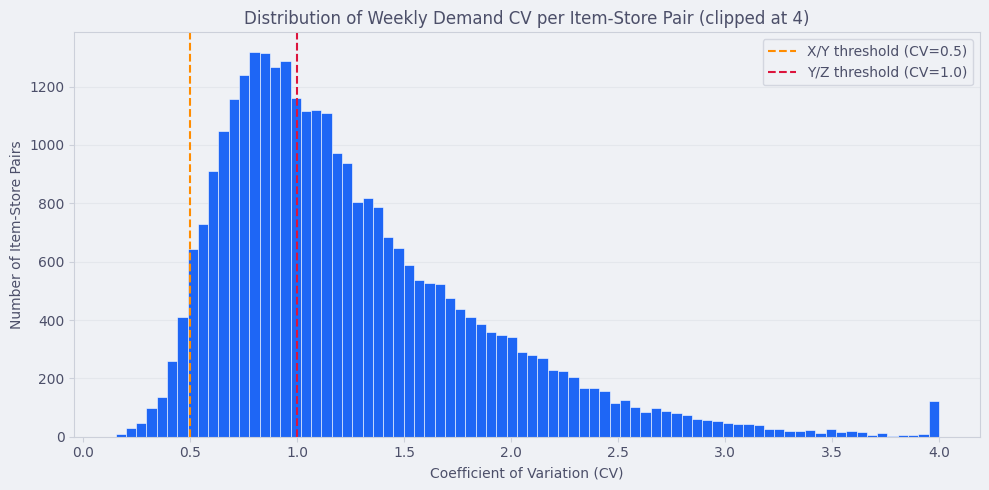

In [113]:
# Weekly demand per item-store pair
weekly_demand = (
    df.assign(week=df["date"].dt.to_period("W"))
    .groupby(["item_id", "store_id", "week"], observed=True)["sales_units"]
    .sum()
    .reset_index()
)

cv_df = (
    weekly_demand.groupby(["item_id", "store_id"], observed=True)["sales_units"]
    .agg(mean_demand="mean", std_demand="std")
    .reset_index()
)
# Protect against divide-by-zero: series with mean=0 sold nothing over the entire window
n_zero_demand = (cv_df["mean_demand"] == 0).sum()
cv_df["cv"] = cv_df["std_demand"] / cv_df["mean_demand"].replace(0, float("nan"))
cv_df_clean = cv_df.dropna(subset=["cv"])
print(f"Dropped {n_zero_demand:,} zero-demand series (mean weekly sales = 0 across full window)")
print(f"Remaining: {len(cv_df_clean):,} item-store pairs\n")

print(f"CV statistics across {len(cv_df_clean):,} item-store pairs:")
print(f"  Min    CV : {cv_df_clean['cv'].min():.2f}")
print(f"  Median CV : {cv_df_clean['cv'].median():.2f}")
print(f"  Mean   CV : {cv_df_clean['cv'].mean():.2f}")
print(f"  Max    CV : {cv_df_clean['cv'].max():.2f}")
print()

# XYZ thresholds
x_thresh, y_thresh = 0.5, 1.0
x_count = (cv_df_clean["cv"] <  x_thresh).sum()
y_count = ((cv_df_clean["cv"] >= x_thresh) & (cv_df_clean["cv"] < y_thresh)).sum()
z_count = (cv_df_clean["cv"] >= y_thresh).sum()
total   = len(cv_df_clean)
print(f"X items (CV < {x_thresh}):                {x_count:,} ({x_count/total:.1%})")
print(f"Y items ({x_thresh} ≤ CV < {y_thresh}): {y_count:,} ({y_count/total:.1%})")
print(f"Z items (CV ≥ {y_thresh}):               {z_count:,} ({z_count/total:.1%})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cv_df_clean["cv"].clip(upper=4), bins=80, edgecolor="white", linewidth=0.4)
ax.axvline(x_thresh, color="darkorange", linestyle="--", linewidth=1.5, label=f"X/Y threshold (CV={x_thresh})")
ax.axvline(y_thresh, color="crimson",    linestyle="--", linewidth=1.5, label=f"Y/Z threshold (CV={y_thresh})")
ax.set_title("Distribution of Weekly Demand CV per Item-Store Pair (clipped at 4)")
ax.set_xlabel("Coefficient of Variation (CV)")
ax.set_ylabel("Number of Item-Store Pairs")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


CV ranges from near-zero to well above 4.0 across the catalogue (the histogram is clipped at 4 for readability; the tail extends further). The printed breakdown above shows the fraction of item-store pairs falling in each XYZ tier at the standard thresholds — the majority will land in Y or Z, confirming that one-size-fits-all safety-stock formulas would be severely mis-calibrated.

XYZ tier implications:

* **X (CV < 0.5):** Demand is predictable; standard statistical safety-stock applies.
* **Y (0.5 ≤ CV < 1.0):** Moderate variability; requires higher buffer multiples.
* **Z (CV ≥ 1.0):** Highly erratic; conventional safety-stock may be prohibitively expensive — MTO or discontinuation policies are worth evaluating, especially for CZ items where low revenue makes large buffers indefensible.

Together with the Pareto analysis, this CV distribution is the empirical foundation for the 9-cell ABC-XYZ matrix and all downstream inventory policy recommendations. **[portfolio]**